In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import textwrap

from dsf_mapping import data_schema as dsf_schema

In [2]:
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [3]:
path = "data/dsf/"
START_YEAR = 2010
END_YEAR = 2020
dsf = pd.read_parquet(
    path, 
    engine="pyarrow",
    # columns=list(CIZ_TO_DSF),
    filters=[("year", ">=", START_YEAR), ("year", "<=", END_YEAR)]
)
dsf.head()

,permno,hdrcusip,permco,siccd,nasdissuno,yyyymmdd,sharetype,securitytype,securitysubtype,usincflg,issuertype,primaryexch,conditionaltype,tradingstatusflg,dlycaldt,dlydelflg,dlyprc,dlyprcflg,dlycap,dlycapflg,dlyprevprc,dlyprevprcflg,dlyprevdt,dlyprevcap,dlyprevcapflg,dlyret,dlyretx,dlyreti,dlyretmissflg,dlyretdurflg,dlyorddivamt,dlynonorddivamt,dlyfacprc,dlydistretflg,dlyvol,dlyclose,dlylow,dlyhigh,dlybid,dlyask,dlyopen,dlynumtrd,dlymmcnt,dlyprcvol,dlycumfacpr,dlycumfacshr,cusip,ticker,exchangetier,shrout,year
0,10001,36720410,7953,4925,10398,20100104,NS,EQTY,COM,Y,CORP,A,RW,A,2010-01-04,N,10.2500,TR,"44,700.2500",BP,10.3000,TR,2009-12-31,"44,918.3000",PB,-0.0049,-0.0049,0.0000,NA,D4,0.0000,0.0000,1.0000,NO,"18,500.0000",10.2500,10.1000,10.5800,10.2100,10.2600,10.5800,<NA>,<NA>,"189,625.0000",1.0000,1.0000,29269V10,EGAS,N/A,4361,2010
1,10002,05978R10,7954,6020,10399,20100104,NS,EQTY,COM,Y,CORP,Q,RW,A,2010-01-04,N,3.1000,TR,"54,665.4000",BP,2.8700,TR,2009-12-31,"50,609.5800",PB,0.0801,0.0801,0.0000,NA,D4,0.0000,0.0000,1.0000,NO,"27,845.0000",3.1000,2.7500,3.2800,3.0100,3.2500,2.8500,109,27,"86,319.5000",1.0000,1.0000,05978R10,BTFG,Q,17634,2010
2,10025,00103110,7975,3081,10432,20100104,NS,EQTY,COM,Y,CORP,Q,RW,A,2010-01-04,N,39.5600,TR,"271,065.1200",BP,38.2800,TR,2009-12-31,"262,294.5600",PB,0.0334,0.0334,0.0000,NA,D4,0.0000,0.0000,1.0000,NO,"33,721.0000",39.5600,38.0000,39.7600,39.5400,39.6200,38.5700,265,25,"1,334,002.8000",1.0000,1.0000,00103110,AEPI,Q,6852,2010
3,10026,46603210,7976,2052,10433,20100104,NS,EQTY,COM,Y,CORP,Q,RW,A,2010-01-04,N,40.2000,TR,"738,634.8000",BP,39.9600,TR,2009-12-31,"734,225.0400",PB,0.0060,0.0060,0.0000,NA,D4,0.0000,0.0000,1.0000,NO,"47,859.0000",40.2000,39.7500,40.5500,40.1300,40.2000,40.5500,667,29,"1,923,931.8000",1.0000,1.0000,46603210,JJSF,Q,18374,2010
4,10028,29402E10,7978,5094,22226,20100104,NS,EQTY,COM,Y,CORP,A,RW,A,2010-01-04,N,1.4001,TR,"13,768.5800",BP,1.4100,TR,2009-12-31,"13,865.9400",PB,-0.0070,-0.0070,0.0000,NA,D4,0.0000,0.0000,1.0000,NO,"3,900.0000",1.4001,1.3300,1.4200,1.4000,1.4200,1.4000,<NA>,<NA>,"5,460.4000",1.0000,1.0000,23323G10,DGSE,N/A,9834,2010


### Daily marketcap (left) and company count (right) by categorical mappings
This cycles through all fields with known mappings from the `dsf_mapping` JSON object and does not represent all categorical fields


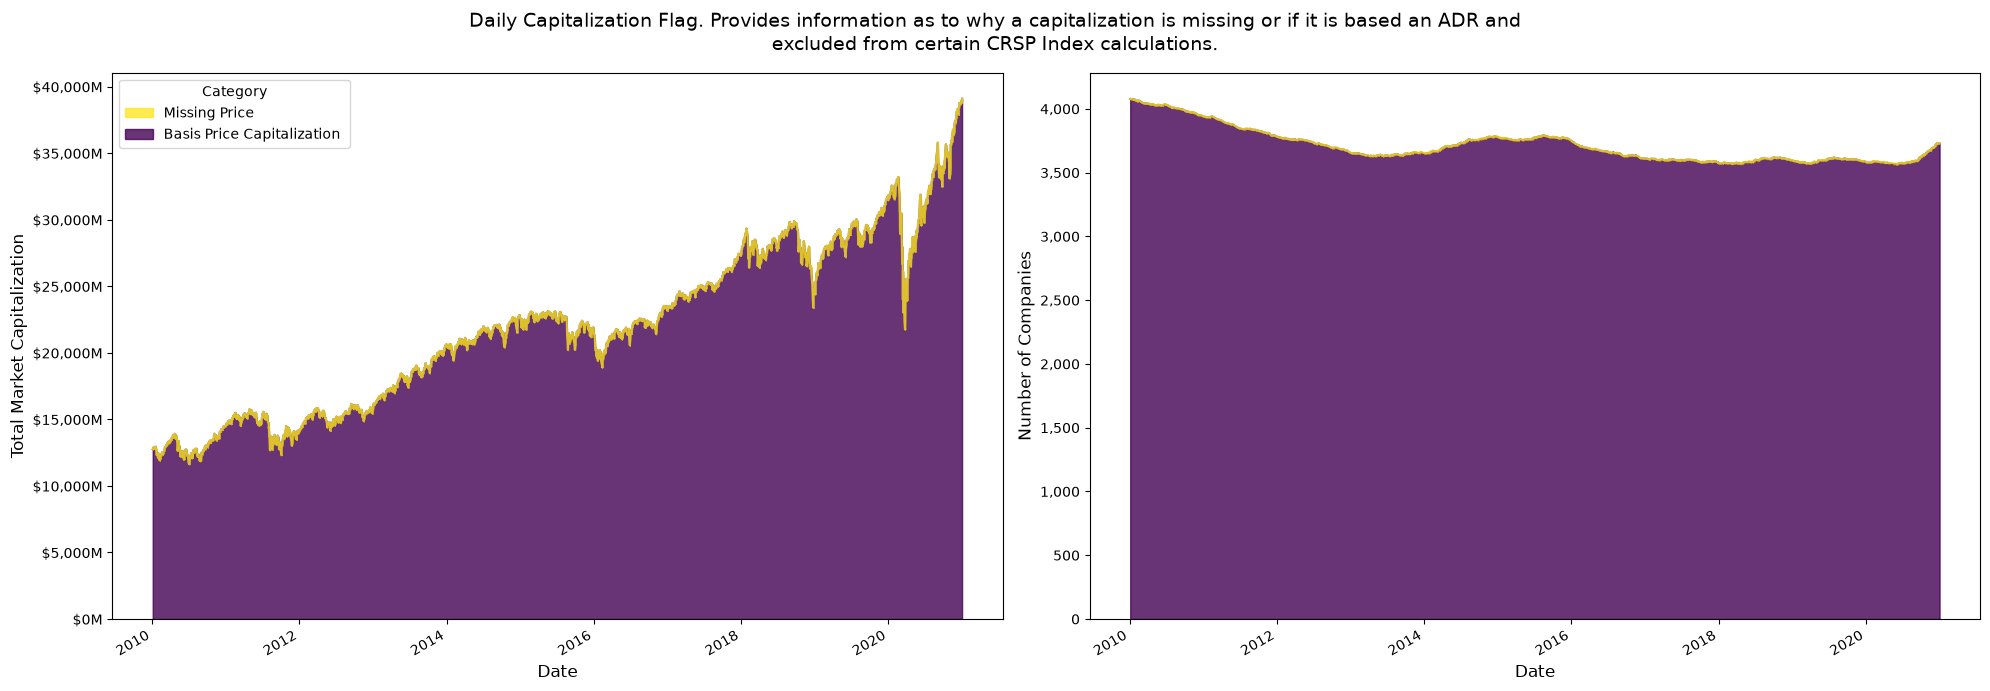

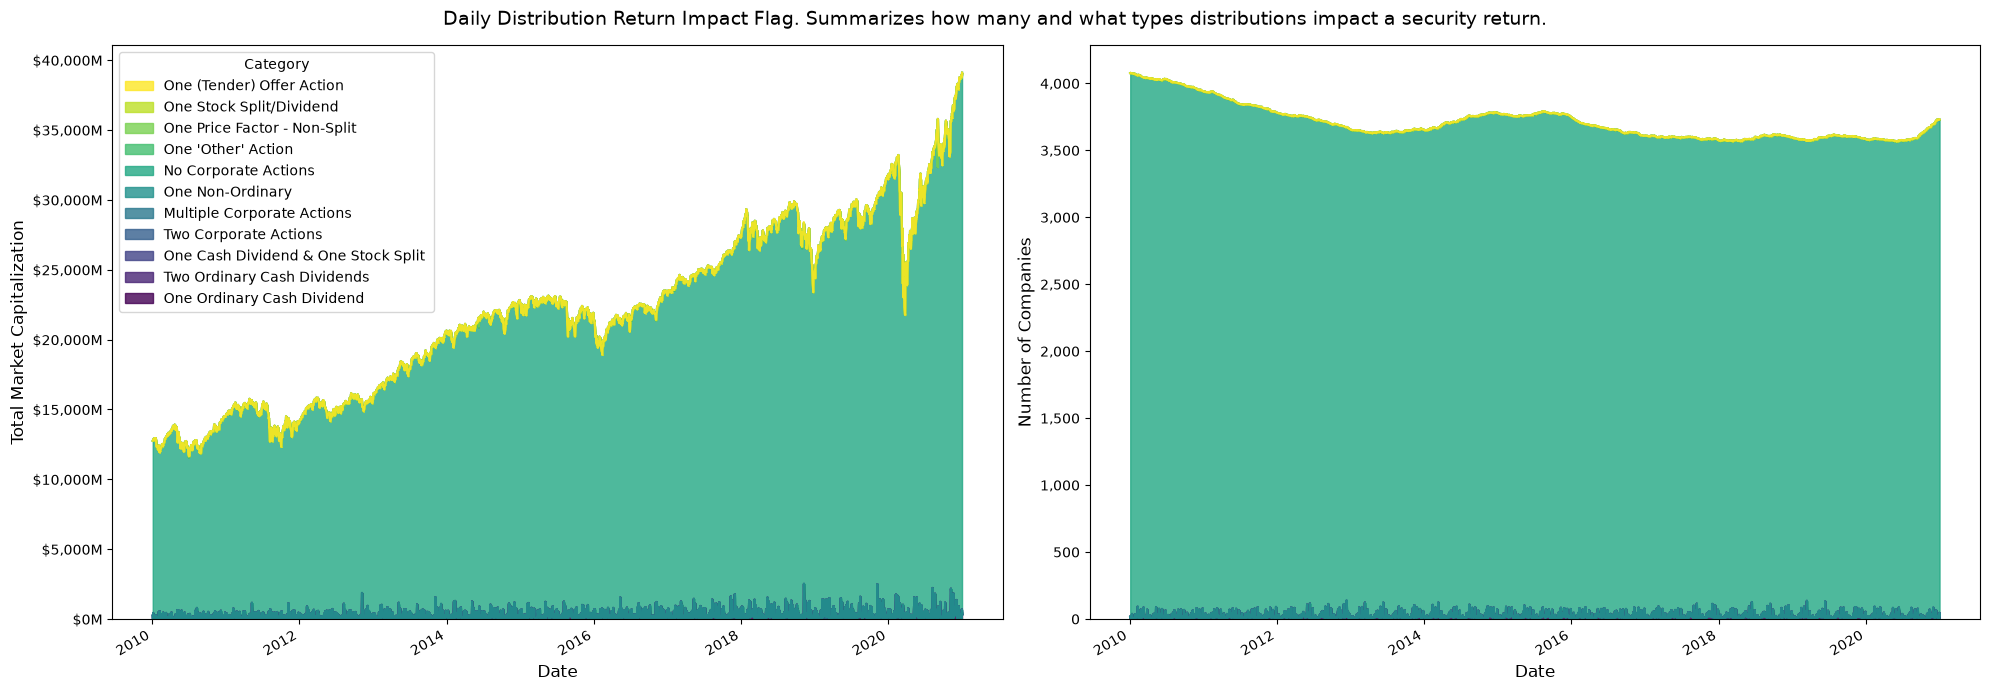

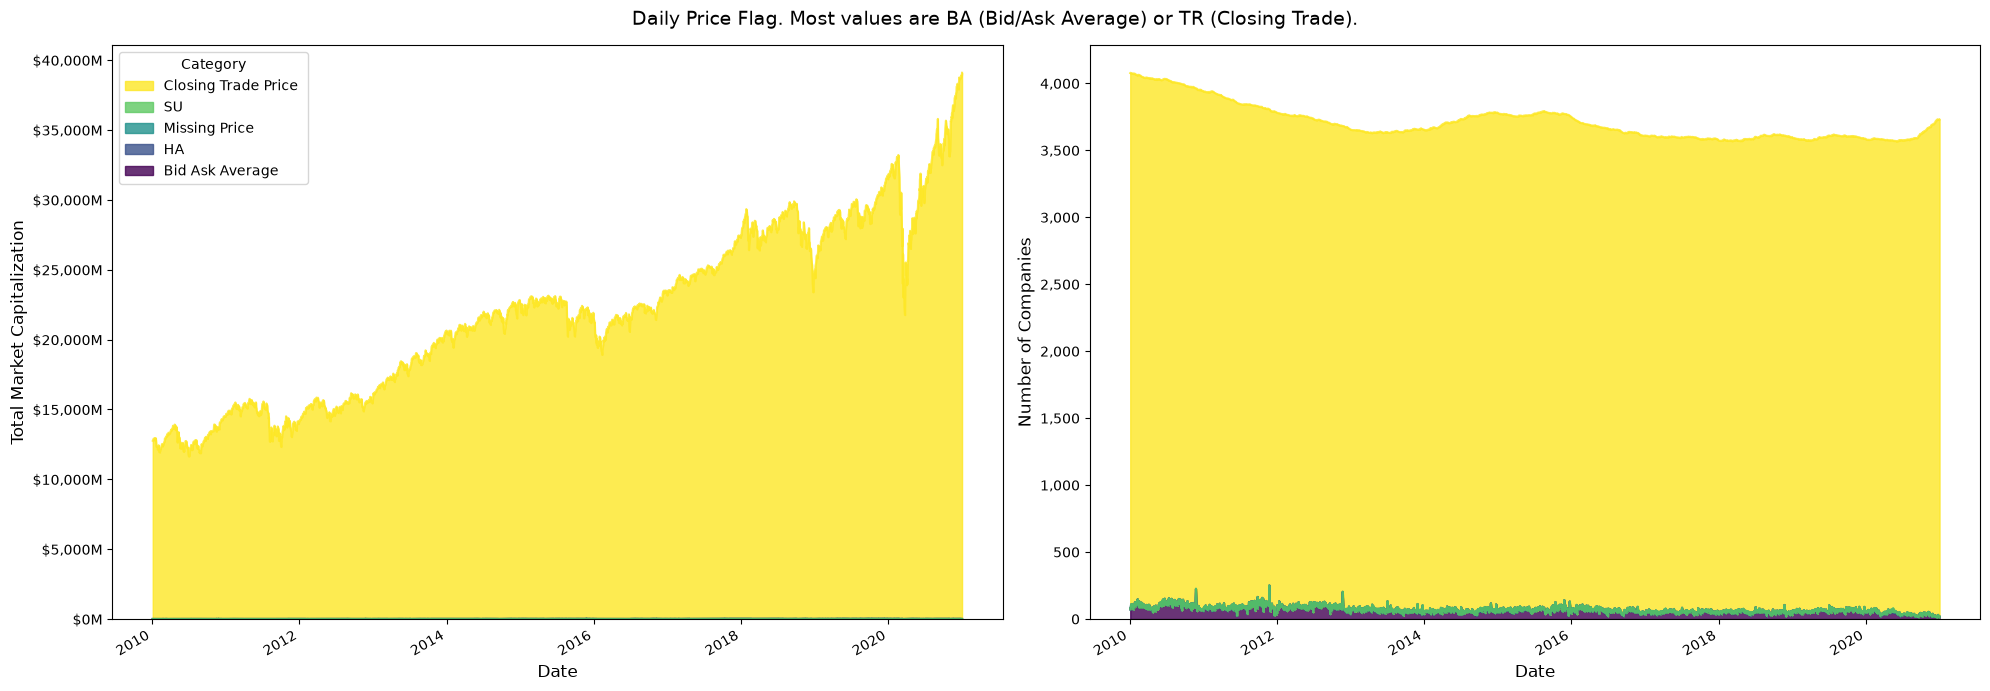

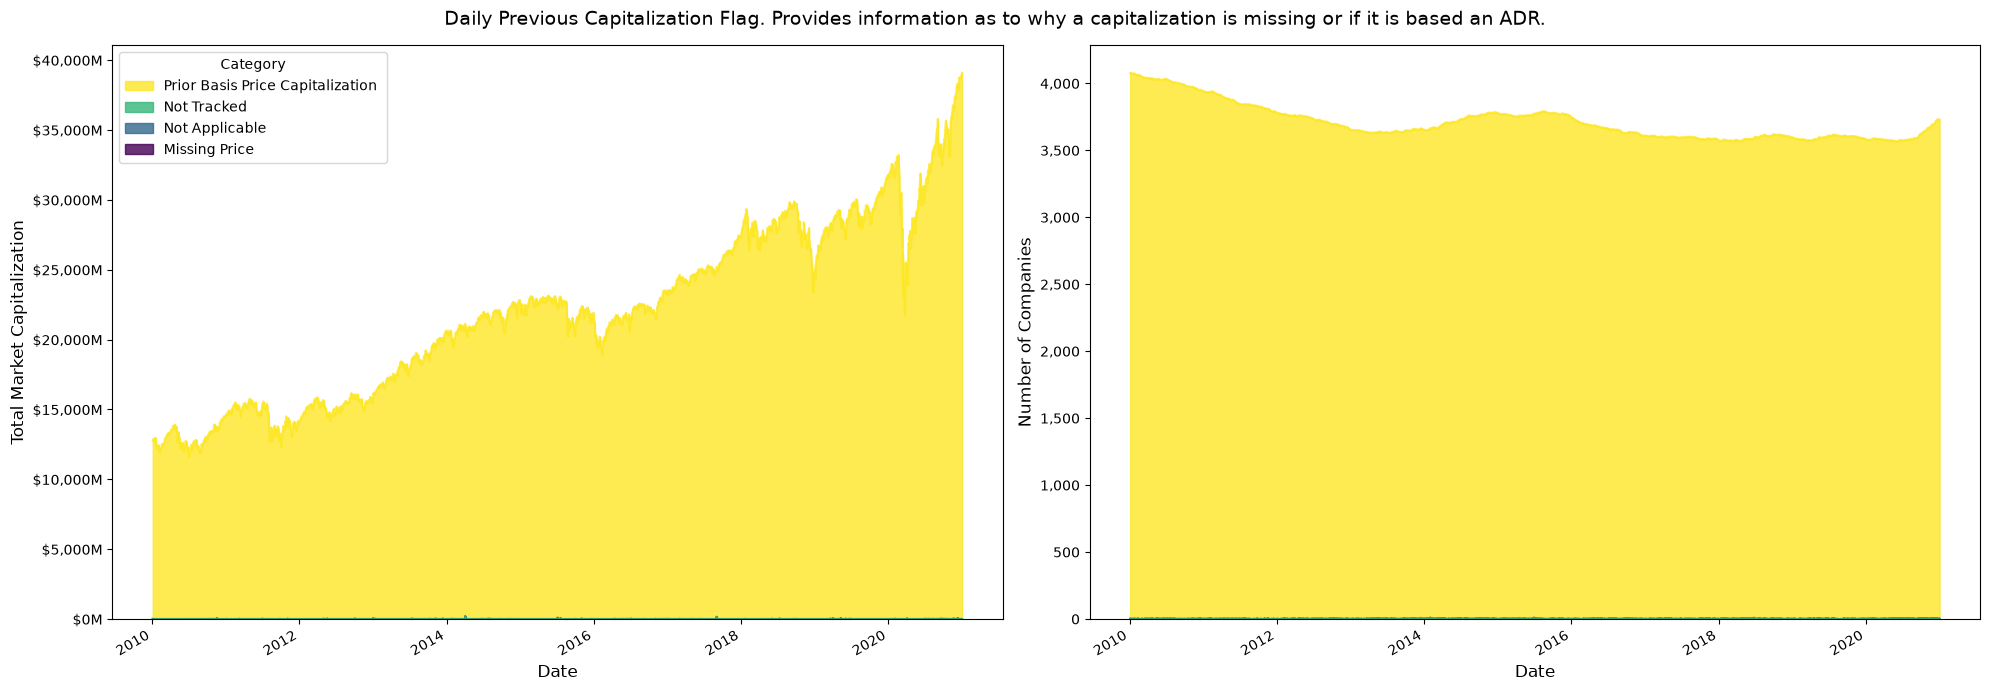

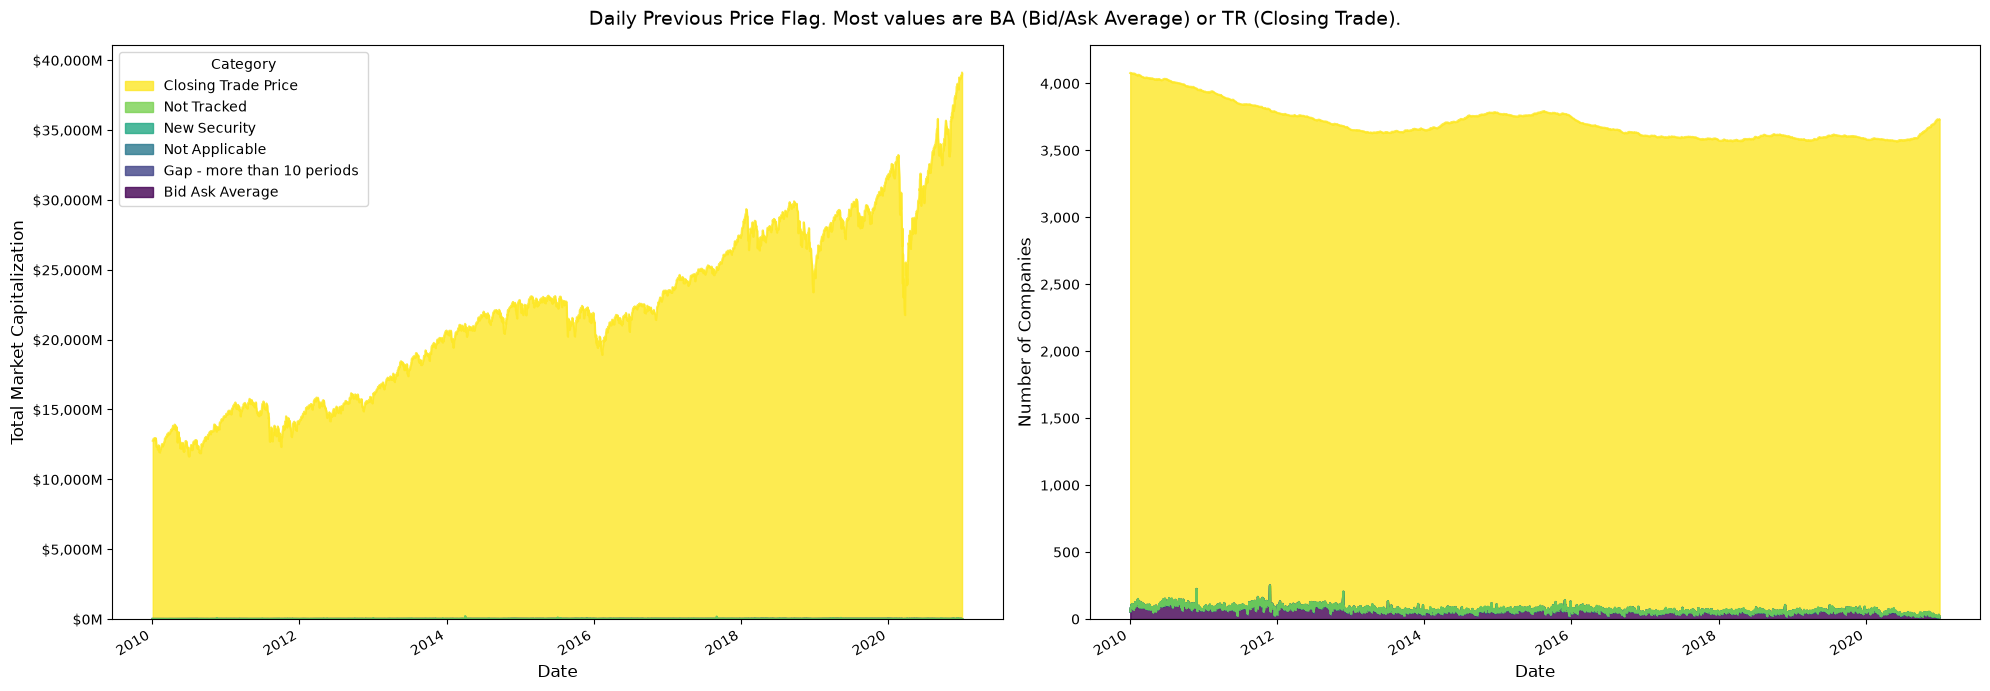

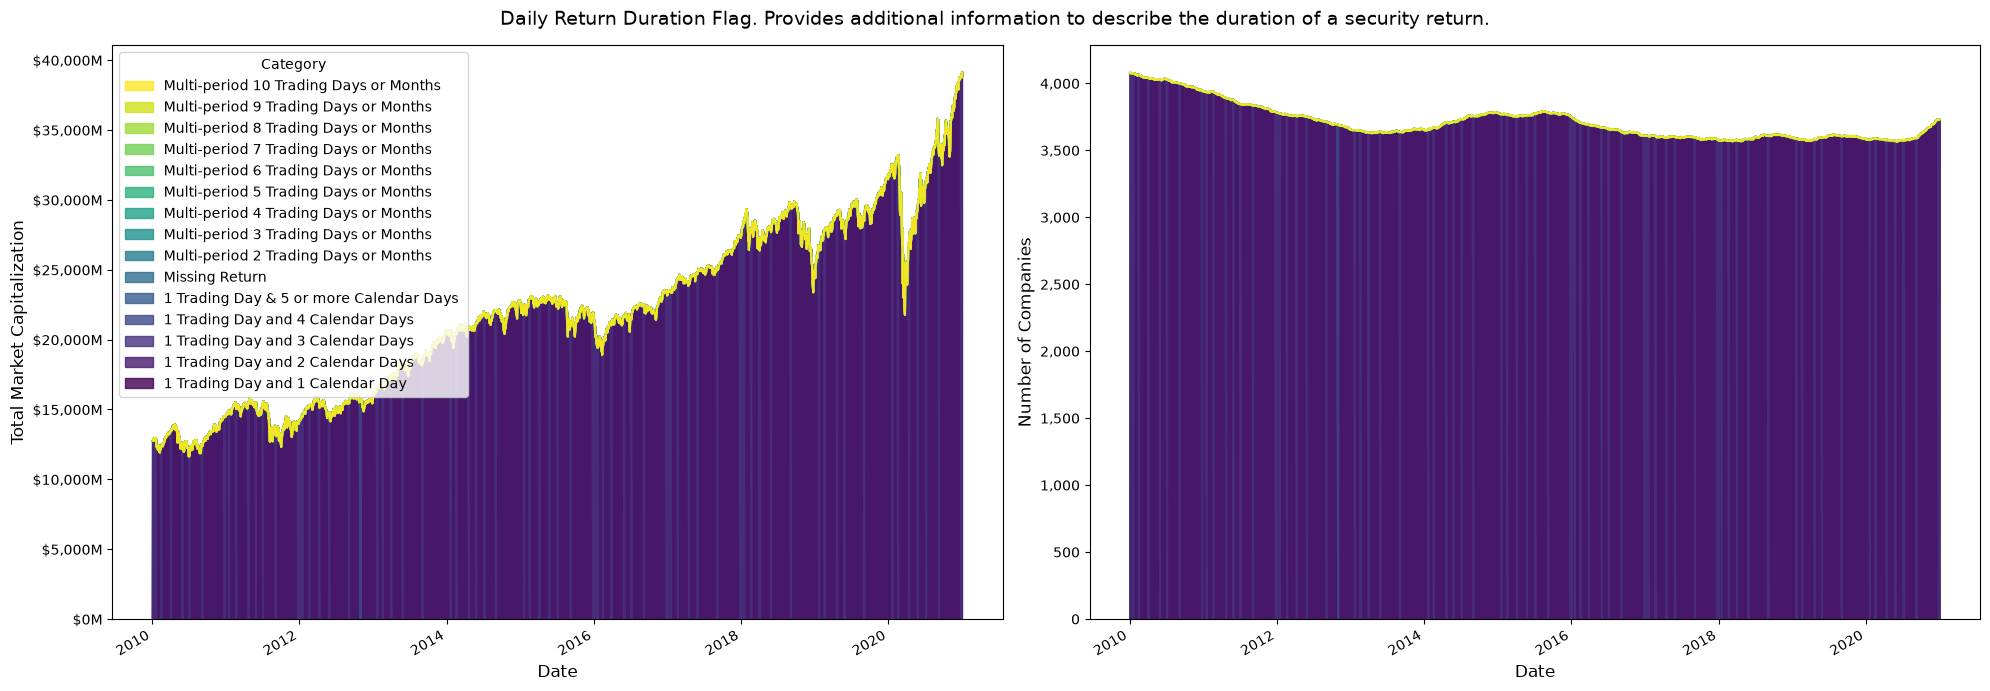

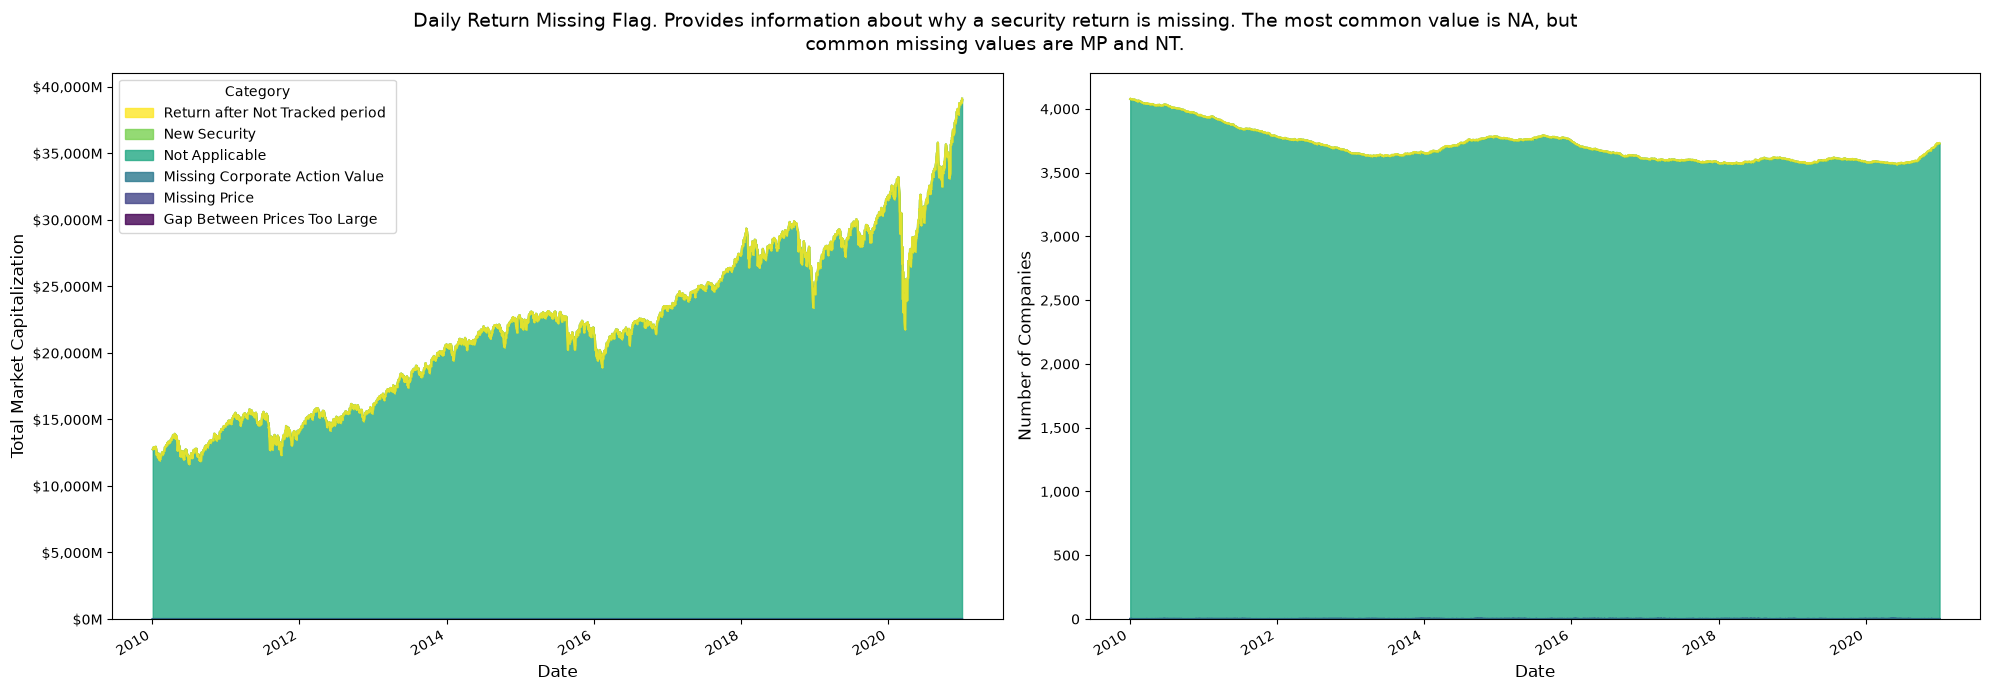

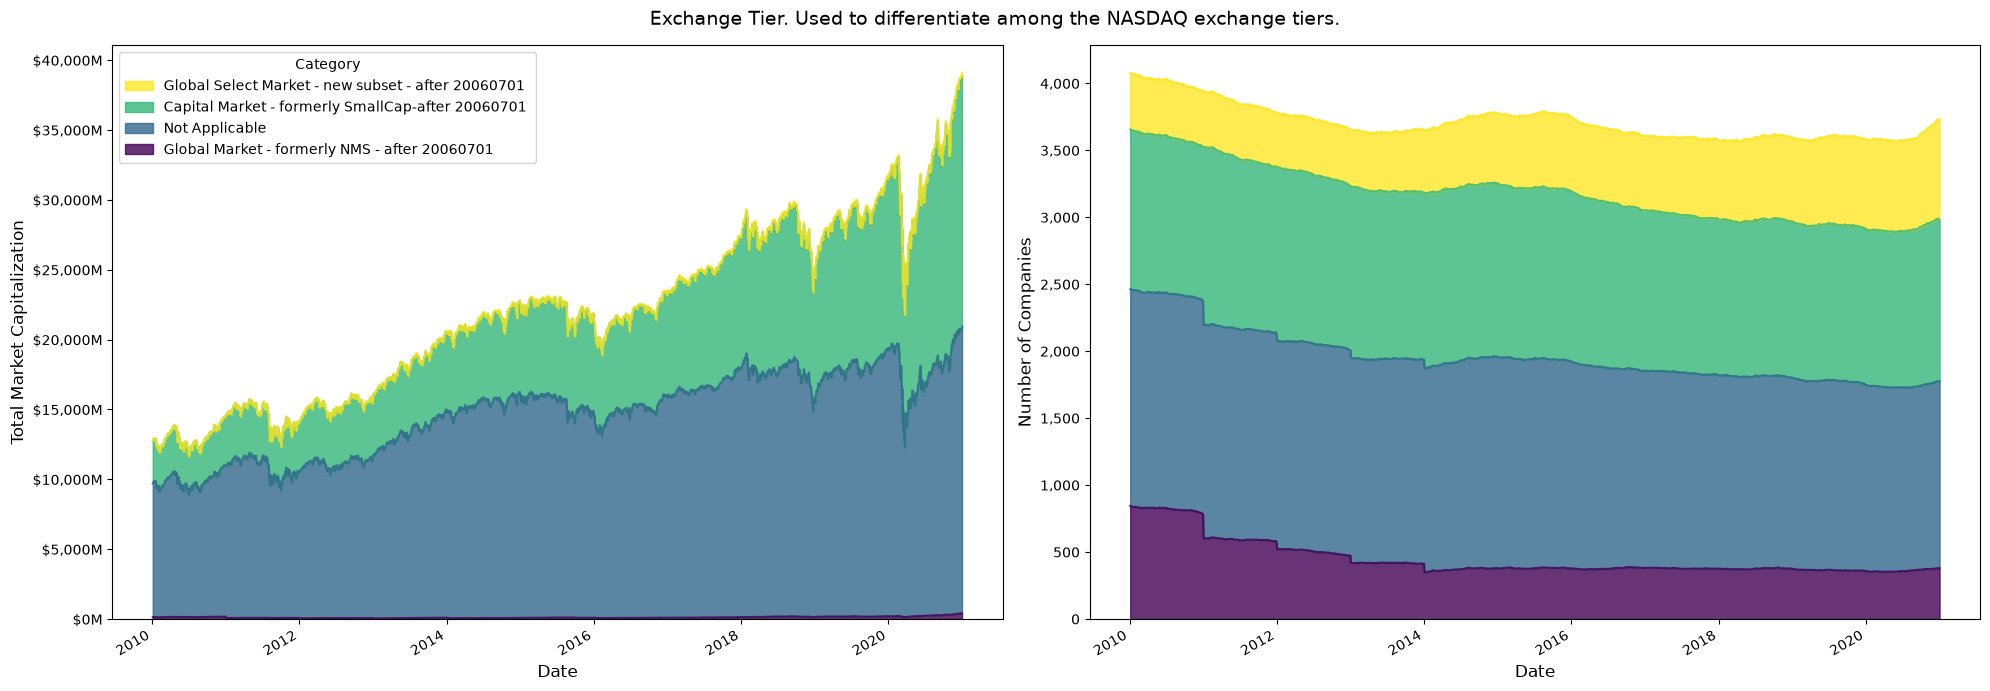

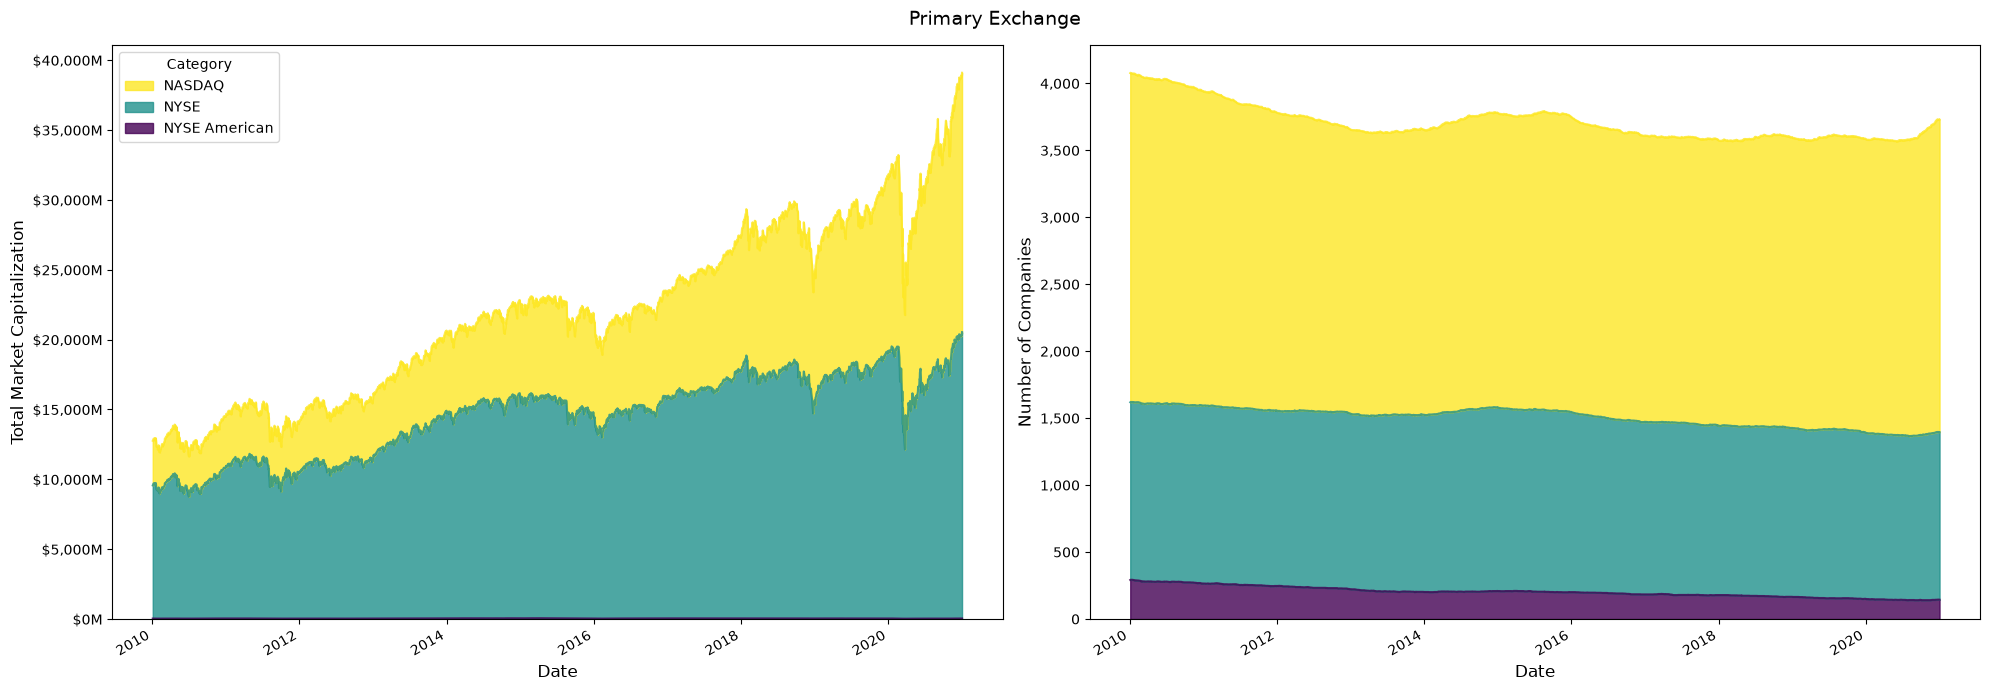

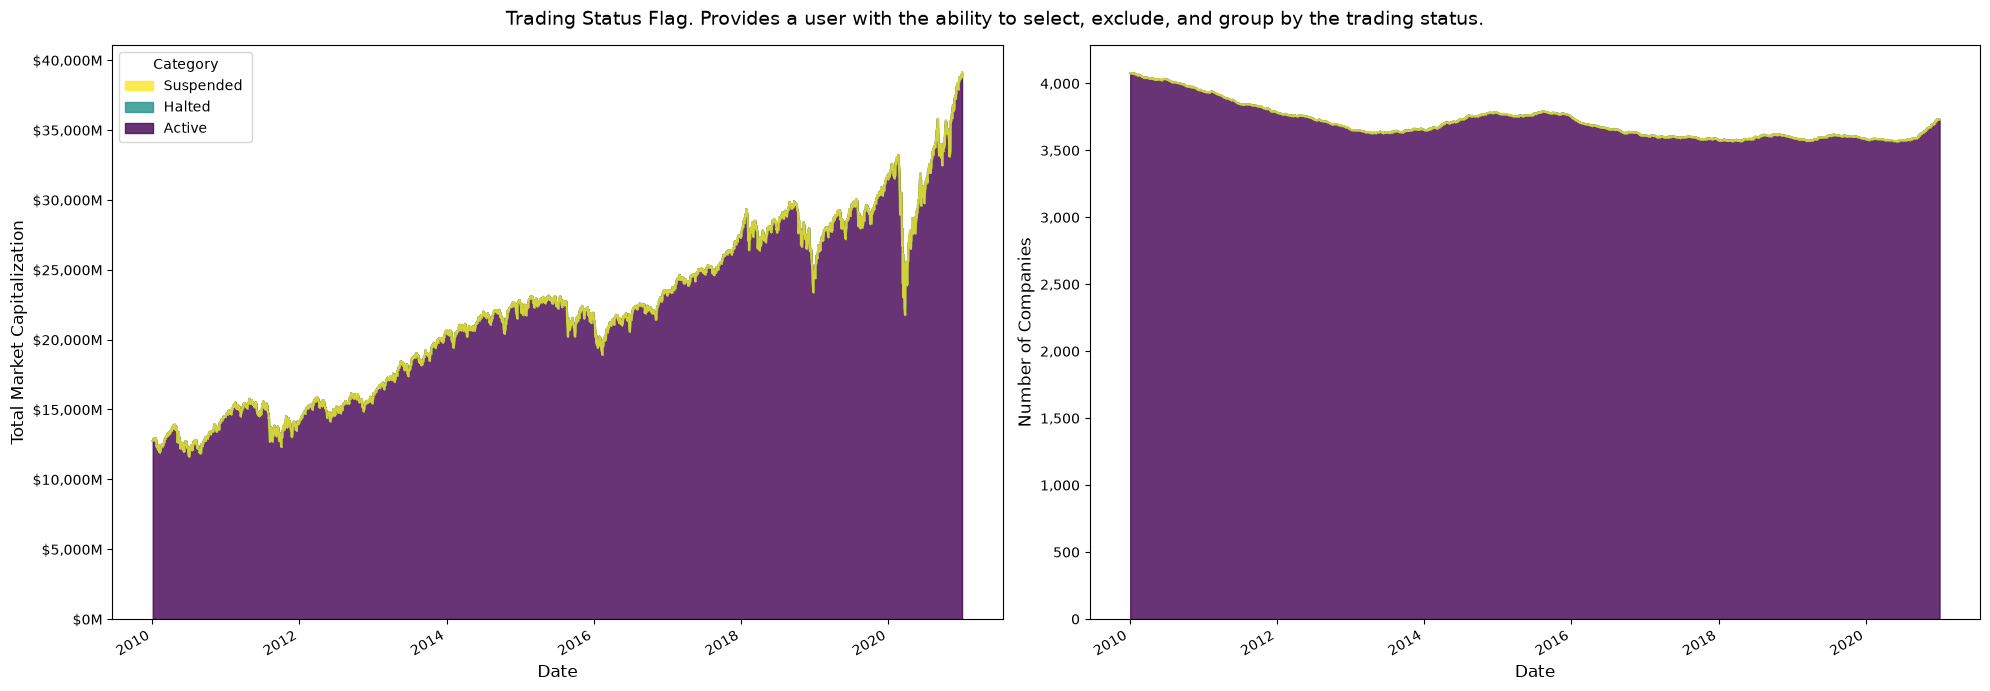


Fields containing only a single mapped value:
| col_name        | description                                                                                                                                                                                                                                         | value                           |
|:----------------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------------------|
| conditionaltype | Conditional Type. This flag provides information about the condition of a security's trading. The most common value by far is RW (Regular Way), but additional codes exist to identify unusual circumstances that might require special processing. | Regular Way                     |
| dlydelflg       | Daily Delisting Flag             

In [4]:

single_category = []

for field, metadata in dsf_schema.items():
    if "mappings" in metadata and field in dsf.columns:
        
        # aggregate marketcap by field/category
        daily_cap = (
            dsf.groupby(['dlycaldt', field])['dlycap']
            .sum()
            .unstack(fill_value=0)
        )
        
        if daily_cap.empty:
            continue

        # If only one item exists in this universe then skip plot, add to text output
        if len(daily_cap.columns) == 1:
            raw_val = daily_cap.columns[0]
            mapped_val = metadata["mappings"].get(raw_val, raw_val)
            single_category.append({
                "col_name": field,
                "description": metadata.get("description", field),
                "value": mapped_val
            })
            continue
            
        daily_cap = daily_cap.rename(columns=metadata["mappings"])
        
        # aggregate permno count by field/category
        daily_count = (
            dsf.groupby(['dlycaldt', field])['permno']
            .nunique()
            .unstack(fill_value=0)
        )
        daily_count = daily_count.rename(columns=metadata["mappings"])
        
        # side by side view
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))
        description = metadata.get('description', field)
        
        # marketcap viz
        daily_cap.plot(kind='area', stacked=True, alpha=0.8, ax=axes[0], colormap='viridis')
        
        # axes[0].set_title(textwrap.fill(f"Daily Market Cap by {description}", width=60), fontsize=14, pad=15)
        wrapped_description = textwrap.fill(description, width=120)
        fig.suptitle(wrapped_description, fontsize=14, y=0.98)
        # fig.suptitle(textwrap.fill(f"Daily Market Cap by {description}", width=60), fontsize=14, pad=15)
        axes[0].set_xlabel("Date", fontsize=12)
        axes[0].set_ylabel("Total Market Capitalization", fontsize=12)
        axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x * 1e-6:,.0f}M')) #format to millions
        
        handles_cap, labels_cap = axes[0].get_legend_handles_labels()
        axes[0].legend(handles_cap[::-1], labels_cap[::-1], title="Category", loc='upper left')
        
        # company count
        daily_count.plot(kind='area', stacked=True, alpha=0.8, ax=axes[1], colormap='viridis', legend=False)
        
        # axes[1].set_title(textwrap.fill(f"Daily Company Count by {description}", width=60), fontsize=14, pad=15)
        axes[1].set_xlabel("Date", fontsize=12)
        axes[1].set_ylabel("Number of Companies", fontsize=12)
        axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
        
        plt.tight_layout()
        plt.show()

# an output of single category values
if single_category:
    df_single_cats = pd.DataFrame(single_category)
    print("\nFields containing only a single mapped value:")
    print(df_single_cats.to_markdown(index=False))
else:
    print("\nNo single-category fields found.")

### IPOs and Exists Quartiles
This viz attempts a crude way of visualizing IPOs vs delisted/exits by checking if company was trading on first or last dates of the time range.
The quartiles help us visualize the balance of companies exiting and entering NASDAQ/NYSE. Nearly 50% of companies listed at the start of 2010 were still listed by the end of 2020.


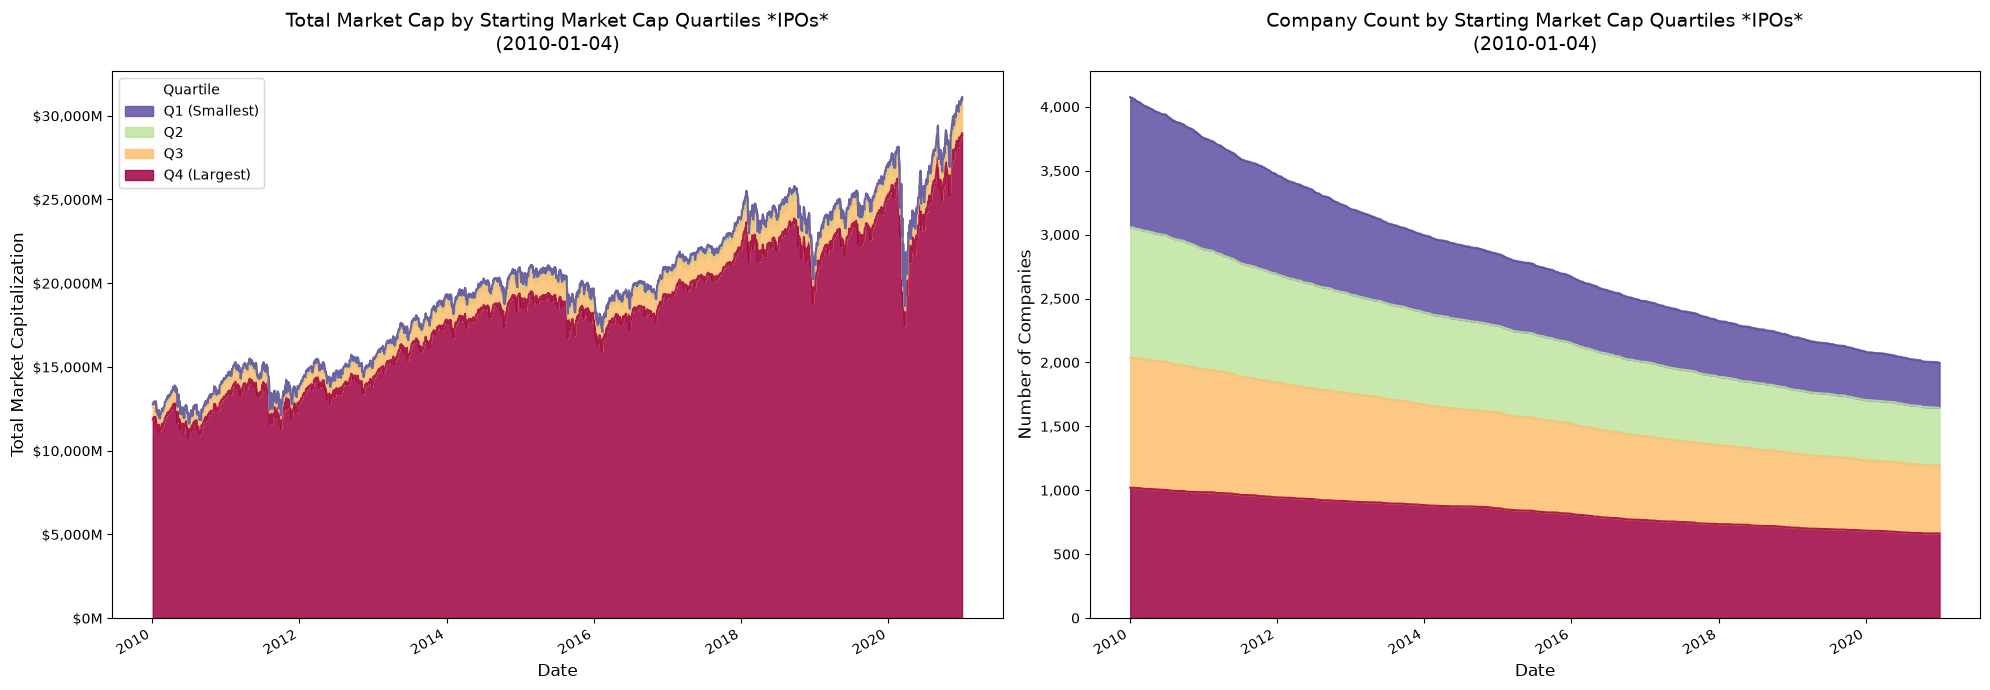

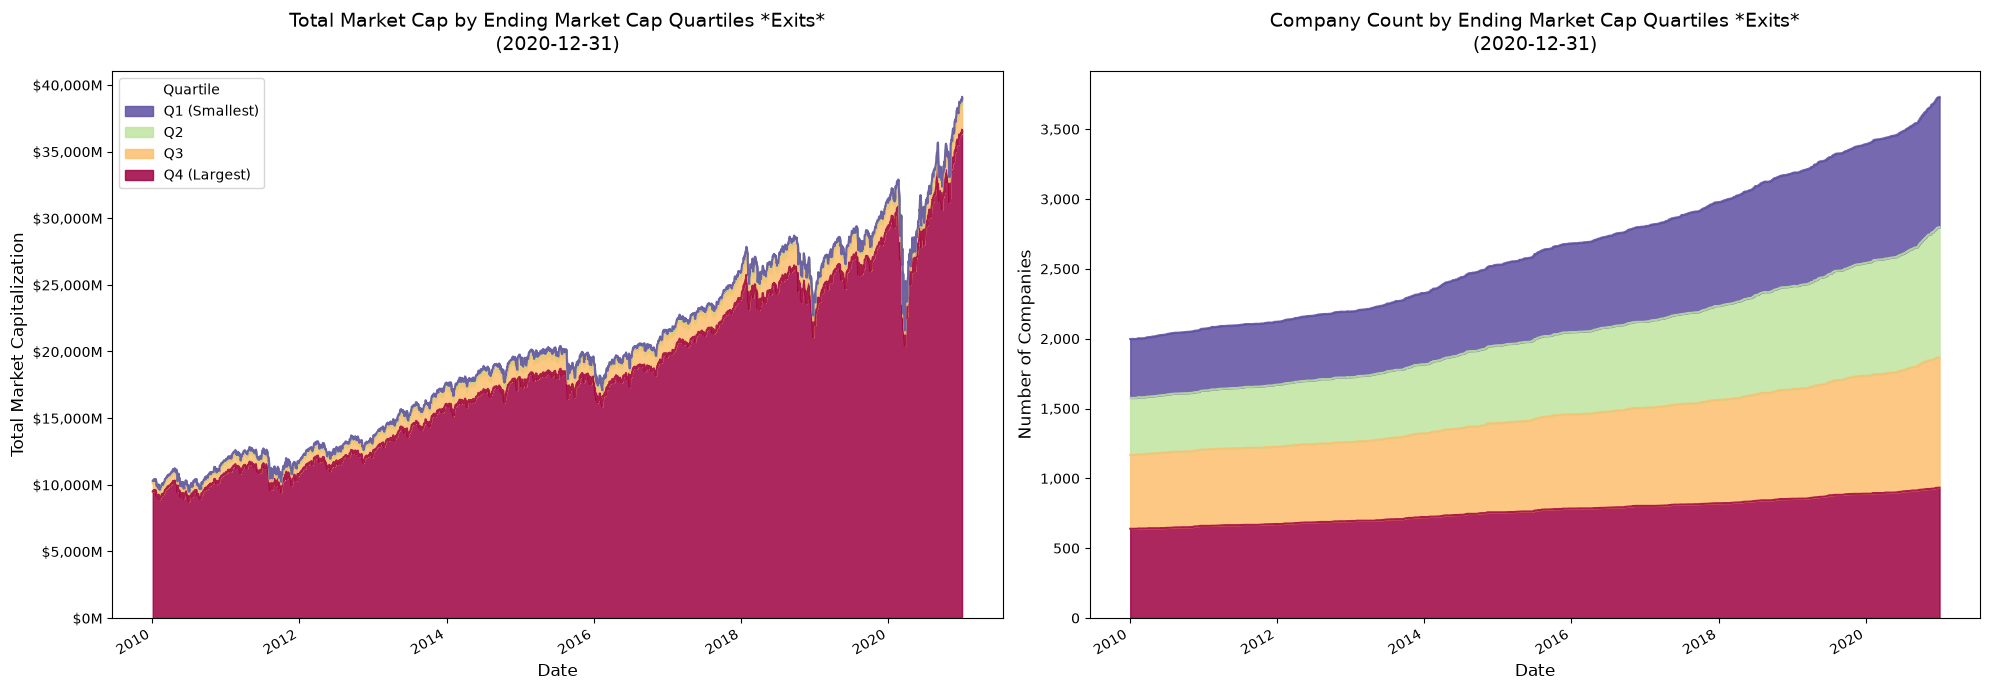

In [5]:

# set first & last dates
first_date = dsf['dlycaldt'].min()
last_date = dsf['dlycaldt'].max()

q_labels = ['Q1 (Smallest)', 'Q2', 'Q3', 'Q4 (Largest)']

start_df = dsf[dsf['dlycaldt'] == first_date].copy()
start_df['Start_Quartile'] = pd.qcut(start_df['dlycap'], q=4, labels=q_labels)

end_df = dsf[dsf['dlycaldt'] == last_date].copy()
end_df['End_Quartile'] = pd.qcut(end_df['dlycap'], q=4, labels=q_labels)

# merge quartiles back to the main panel data
dsf_merged = dsf.merge(start_df[['permno', 'Start_Quartile']], on='permno', how='left')
dsf_merged = dsf_merged.merge(end_df[['permno', 'End_Quartile']], on='permno', how='left')

# companies that were unlisted on first & last dates (IPOs / Delistings)
dsf_merged['Start_Quartile'] = dsf_merged['Start_Quartile'].astype(str).replace('nan', 'Unlisted at Start (IPOs)')
dsf_merged['End_Quartile'] = dsf_merged['End_Quartile'].astype(str).replace('nan', 'Unlisted at End (Exits)')

quartile_views = {
    'Start_Quartile': f'Starting Market Cap Quartiles *IPOs* ({first_date.strftime("%Y-%m-%d")})',
    'End_Quartile': f'Ending Market Cap Quartiles *Exits* ({last_date.strftime("%Y-%m-%d")})'
}

for col, desc in quartile_views.items():
    
    # Aggregations
    daily_cap = dsf_merged.groupby(['dlycaldt', col])['dlycap'].sum().unstack(fill_value=0)
    daily_count = dsf_merged.groupby(['dlycaldt', col])['permno'].nunique().unstack(fill_value=0)
    
    col_order = ['Q4 (Largest)', 'Q3', 'Q2', 'Q1 (Smallest)', 
                 'Unlisted at Start (IPOs)' if 'Start' in col else 'Unlisted at End (Exits)']
    
    col_order = [c for c in col_order if c in daily_cap.columns]
    
    daily_cap = daily_cap[col_order]
    daily_count = daily_count[col_order]
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))
    
    # marketcap
    daily_cap.plot(kind='area', stacked=True, alpha=0.85, ax=axes[0], colormap='Spectral')
    axes[0].set_title(textwrap.fill(f"Total Market Cap by {desc}", width=60), fontsize=14, pad=15)
    axes[0].set_xlabel("Date", fontsize=12)
    axes[0].set_ylabel("Total Market Capitalization", fontsize=12)
    axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x * 1e-6:,.0f}M'))
    
    handles_cap, labels_cap = axes[0].get_legend_handles_labels()
    axes[0].legend(handles_cap[::-1], labels_cap[::-1], title="Quartile", loc='upper left')
    
    # comapny count
    daily_count.plot(kind='area', stacked=True, alpha=0.85, ax=axes[1], colormap='Spectral', legend=False)
    axes[1].set_title(textwrap.fill(f"Company Count by {desc}", width=60), fontsize=14, pad=15)
    axes[1].set_xlabel("Date", fontsize=12)
    axes[1].set_ylabel("Number of Companies", fontsize=12)
    axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.tight_layout()
    plt.show()

## Delisted companies

In [6]:
path = "data/crsp_delist.parquet"
START_YEAR = 2010
END_YEAR = 2020
delisted = pd.read_parquet(
    path, 
    engine="pyarrow",
    # columns=list(CIZ_TO_DSF),
    # filters=[("year", ">=", START_YEAR), ("year", "<=", END_YEAR)]
)
delisted.head()

,permno,delistingdt,deldtprc,deldtprcflg,delactiontype,delstatustype,delreasontype,delpaymenttype,delpermno,delpermco,delret,delretmisstype,delnextdt,delnextprc,delnextprcflg,delamtdt,deldivamt,deldistype,deldlydt
0,10000,1987-06-11,0.2188,BA,GDR,VCL,INSC,PRCF,0,0,0.0000,NA,1987-06-12,0.2188,DP,1987-06-12,0.0000,NO,1987-06-12
1,10001,2017-08-03,13.1000,TR,MER,FPAY,UNAV,CASH,0,0,0.0000,NA,<NA>,<NA>,DA,2017-08-04,13.1000,D1,2017-08-04
2,10002,2013-02-15,2.9800,TR,MER,FPAY,UNAV,STK,35263,1658,0.0109,NA,<NA>,<NA>,DA,2013-02-19,3.0125,D1,2013-02-19
3,10003,1995-12-15,5.4688,TR,MER,FPAY,UNAV,STK,10569,8477,-0.0036,NA,<NA>,<NA>,DA,1995-12-18,5.4488,D1,1995-12-18
4,10004,1986-01-17,6.8750,BA,GDR,VCL,OFFRE,PRCF,0,0,<NA>,DM,<NA>,<NA>,DM,<NA>,<NA>,NO,1986-01-20


### Looking at delisted companies' accumlated marketcap by delisted reason
Not all delistings are bad. Though the data does not directly spell out the good reasons for delisting, here we can see that the accumlative amount of market capitlization that's left the markets over the time period.

In [7]:

# last observed market cap per company, i.e. its size on the way out
exit_cap = (
    dsf.dropna(subset=['dlycap'])
    .sort_values('dlycaldt')
    .groupby('permno')['dlycap']
    .last()
)

# one row per delisting event, limited to exits inside the dsf window
in_window = delisted['delistingdt'].between(f'{START_YEAR}-01-01', f'{END_YEAR}-12-31')
exit_data = delisted[in_window & delisted['permno'].isin(exit_cap.index)].copy()

# index labels carry over from `delisted` so the Reason assignment below still aligns
exit_data['dlycap'] = exit_data['permno'].map(exit_cap)

print(f"delisting events in window: {len(exit_data):,}")
print(f"market cap leaving the market: ${exit_data['dlycap'].sum() * 1e-6:,.0f}M")
exit_data[['permno', 'delistingdt', 'delreasontype', 'dlycap']].head()

delisting events in window: 2,679
market cap leaving the market: $5,173M


,permno,delistingdt,delreasontype,dlycap
1,10001,2017-08-03,UNAV,"137,812.0000"
2,10002,2013-02-15,UNAV,"53,538.6800"
25,10025,2017-01-20,UNAV,"562,284.3000"
68,10078,2010-01-26,UNAV,"7,154,890.6000"
82,10092,2010-05-28,INSC,"9,754.9700"


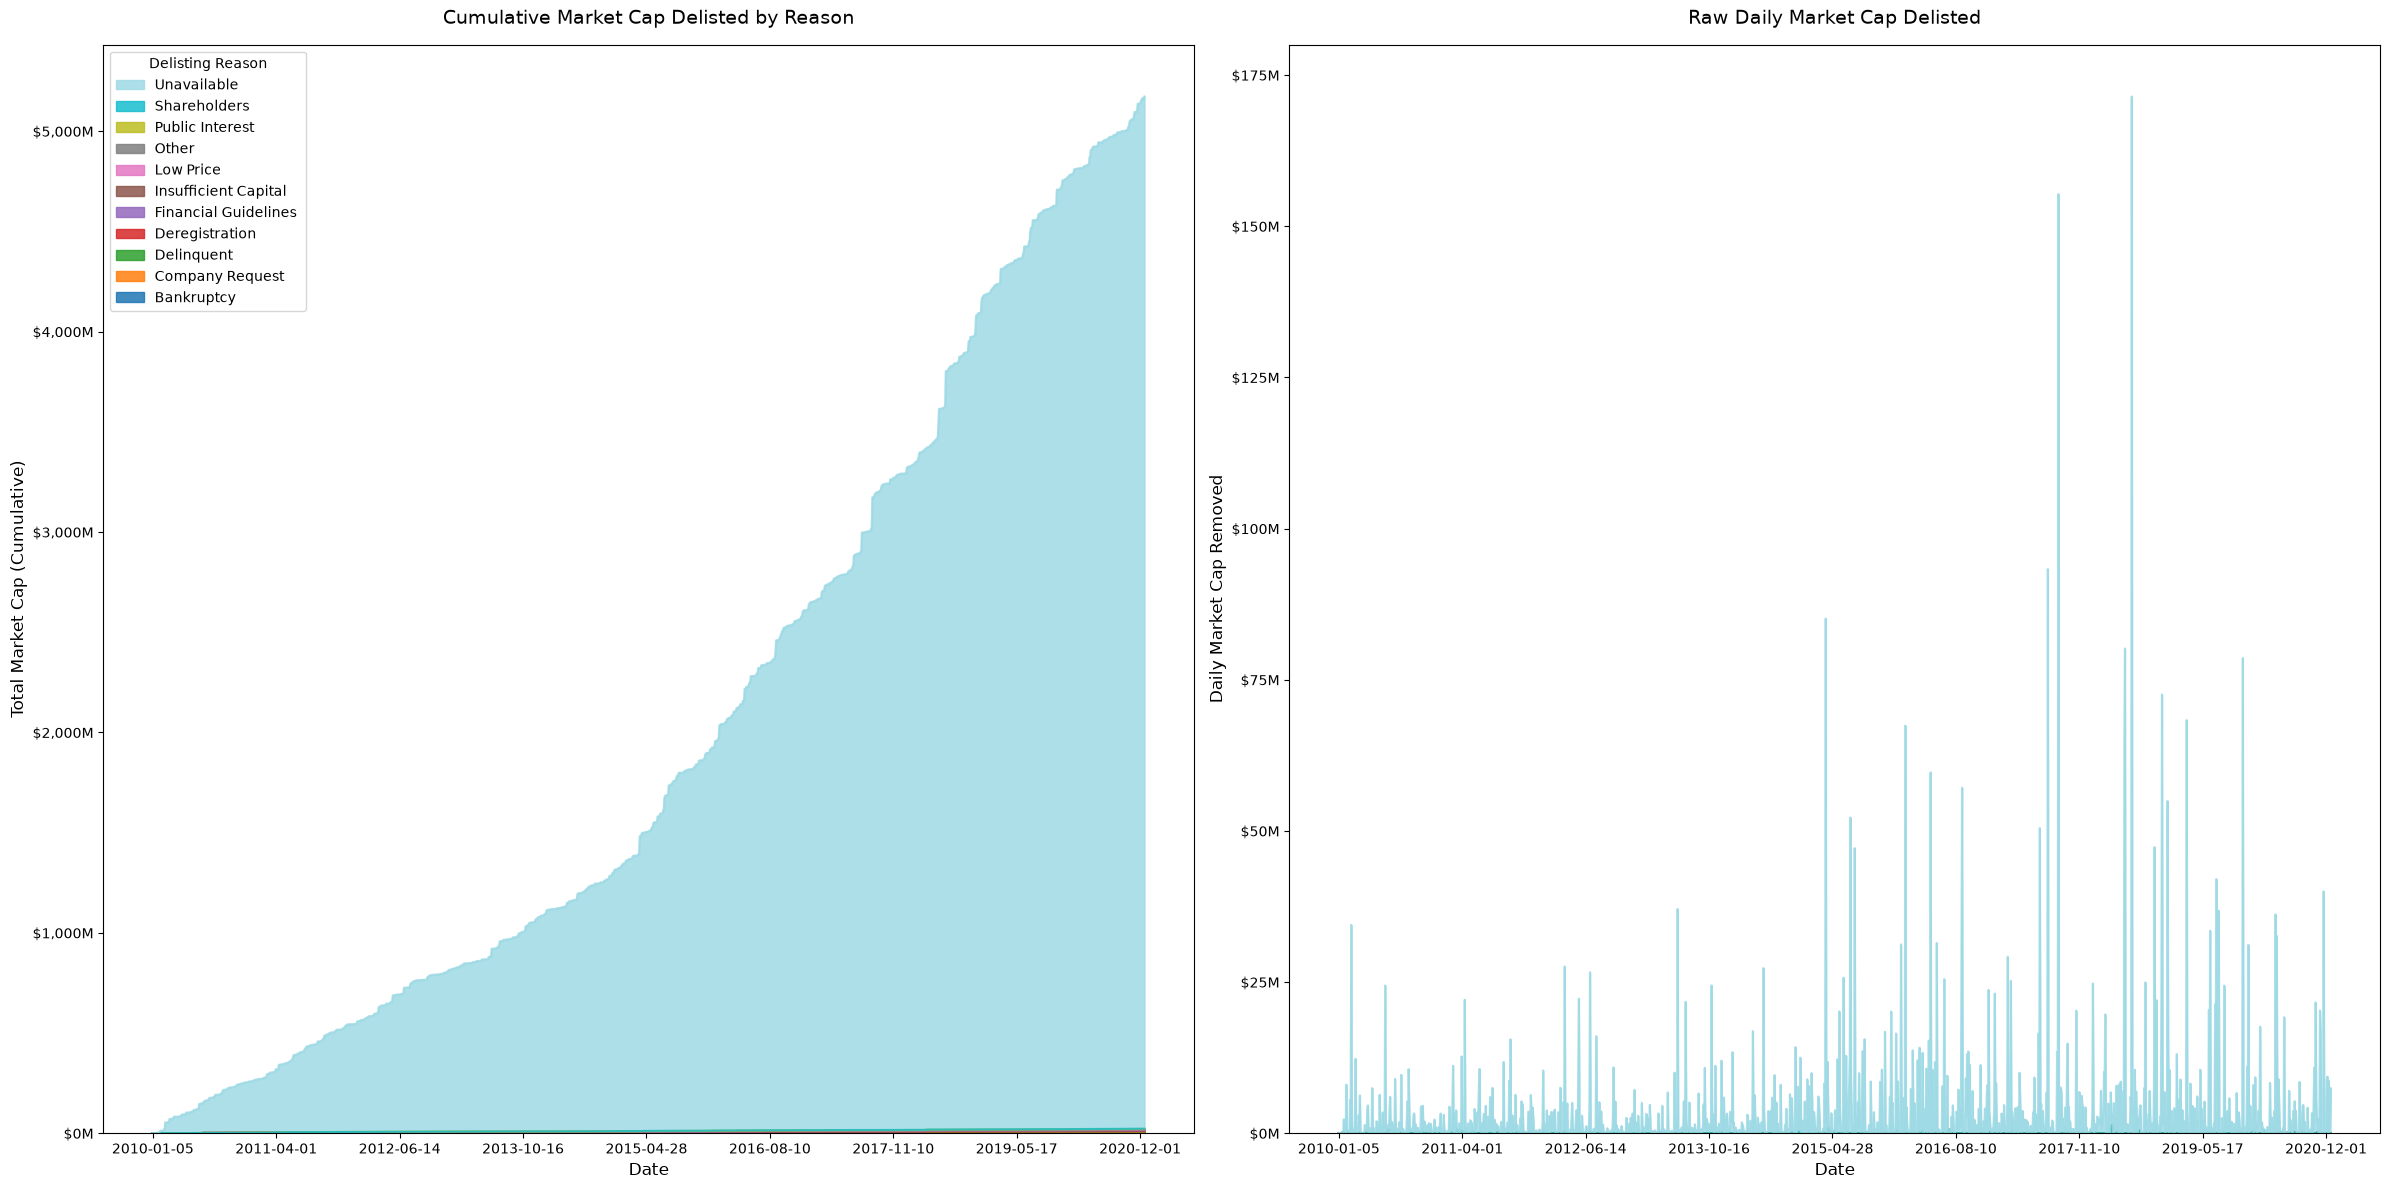

In [8]:

reason_map = dsf_schema.get('delreasontype', {}).get('mappings')

exit_data['Reason'] = delisted['delreasontype'].astype(str)

exit_data['Reason'] = exit_data['Reason'].map(reason_map).fillna('Other / Unknown')
top_10_reasons = exit_data.groupby('Reason')['dlycap'].sum().nlargest(10).index
exit_data['Reason'] = exit_data['Reason'].where(exit_data['Reason'].isin(top_10_reasons), 'Other')

# raw daily aggregate
daily_exit_cap = (
    exit_data.groupby(['delistingdt', 'Reason'])['dlycap']
    .sum()
    .unstack(fill_value=0)
)

# cumulative aggregate exit marketcap
cumulative_exit_cap = daily_exit_cap.cumsum()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(24, 12))

# cumulative marketcap
cumulative_exit_cap.plot(kind='area', stacked=True, alpha=0.85, ax=axes[0], colormap='tab20')

axes[0].set_title("Cumulative Market Cap Delisted by Reason", fontsize=14, pad=15)
axes[0].set_xlabel("Date", fontsize=12)
axes[0].set_ylabel("Total Market Cap (Cumulative)", fontsize=12)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x * 1e-6:,.0f}M'))

# legend inside the first chart
handles_cum, labels_cum = axes[0].get_legend_handles_labels()
axes[0].legend(handles_cum[::-1], labels_cum[::-1], title="Delisting Reason", loc='upper left')

# raw daily market Cap exits
daily_exit_cap.plot(kind='area', stacked=True, alpha=0.85, ax=axes[1], colormap='tab20', legend=False)

axes[1].set_title("Raw Daily Market Cap Delisted", fontsize=14, pad=15)
axes[1].set_xlabel("Date", fontsize=12)
axes[1].set_ylabel("Daily Market Cap Removed", fontsize=12)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x * 1e-6:,.0f}M'))

plt.tight_layout()
plt.show()

### Daily Market Cap of delisted companies
This viz shows what the fall of delisted companies looked like by the end of 2020 (Pre-2021 Delisted) and what comapnies will eventually be delisted after Decemenber of 2020 (Post-2020 Delisted). 

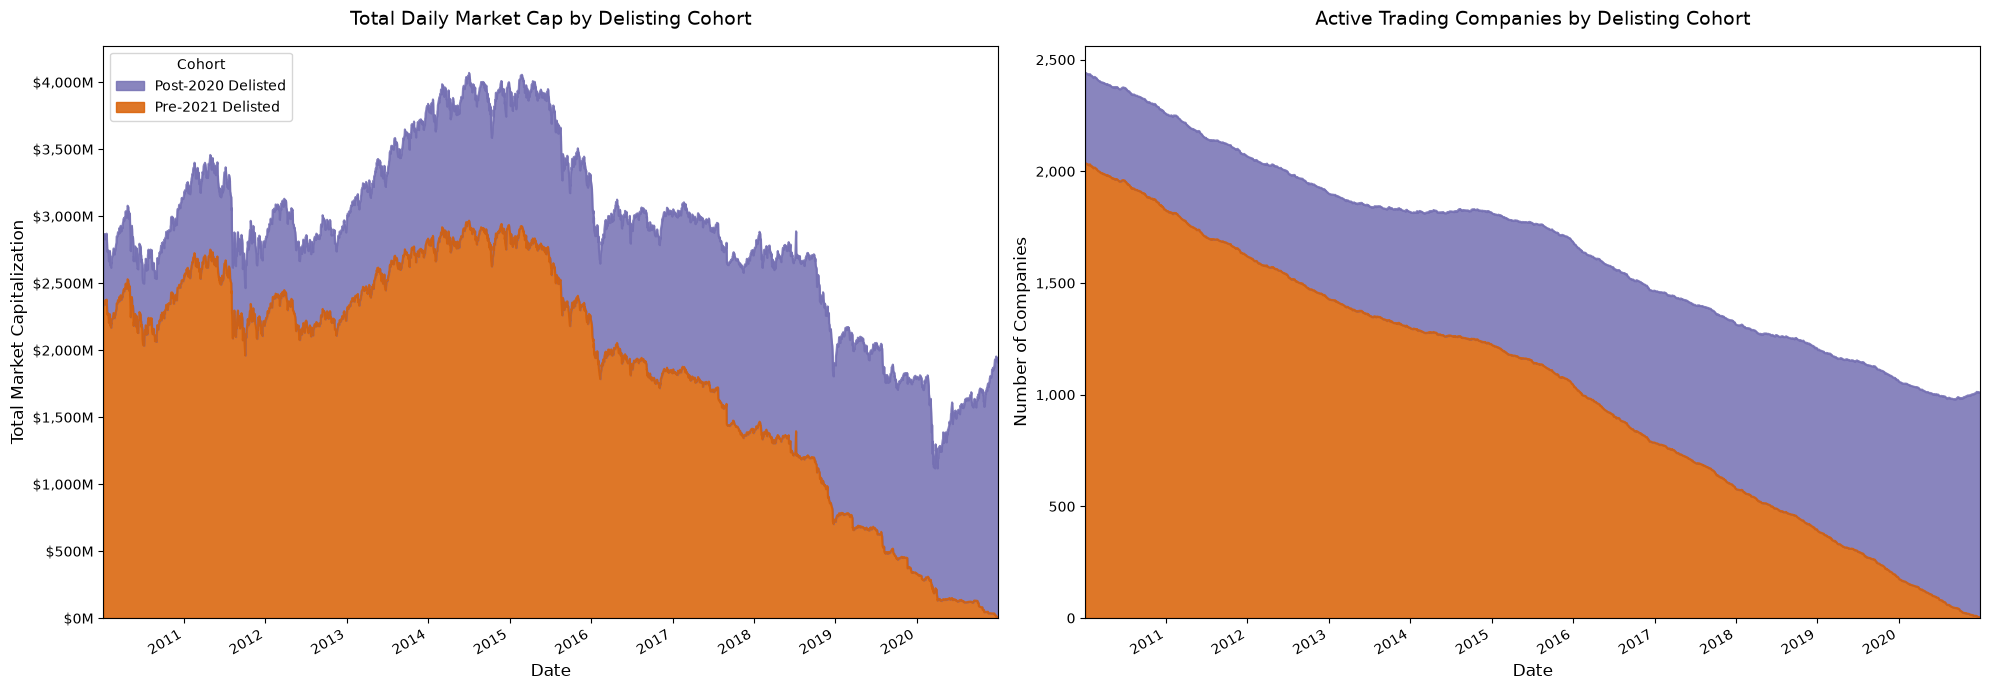

In [10]:


cutoff_date = pd.to_datetime('2020-12-31')

# compare the delist cohort
delisted['Cohort'] = np.where(
    pd.to_datetime(delisted['delistingdt']) <= cutoff_date, 
    'Pre-2021 Delisted', 
    'Post-2020 Delisted'
)

# cohort mapping of delist
cohort_map = delisted[['permno', 'Cohort']].drop_duplicates(subset=['permno'], keep='last')

# only companies that are in the delisted universe
dsf_delisted = dsf[dsf['permno'].isin(cohort_map['permno'])].copy()

# attach cohort to their daily trading history
dsf_delisted = pd.merge(dsf_delisted, cohort_map, on='permno', how='left')

# aggregate dailies by date and cohort
daily_cap = (
    dsf_delisted.groupby(['dlycaldt', 'Cohort'])['dlycap']
    .sum()
    .unstack(fill_value=0)
)

daily_count = (
    dsf_delisted.groupby(['dlycaldt', 'Cohort'])['permno']
    .nunique()
    .unstack(fill_value=0)
)

# fix order so colors are consistent
cols_order = ['Pre-2021 Delisted', 'Post-2020 Delisted']
daily_cap = daily_cap.reindex(columns=cols_order, fill_value=0)
daily_count = daily_count.reindex(columns=cols_order, fill_value=0)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))

cohort_colors = ['#d95f02', '#7570b3']

# daily marketcap
daily_cap.plot(kind='area', stacked=True, ax=axes[0], color=cohort_colors, alpha=0.85)

axes[0].set_title("Total Daily Market Cap by Delisting Cohort", fontsize=14, pad=15)
axes[0].set_xlabel("Date", fontsize=12)
axes[0].set_ylabel("Total Market Capitalization", fontsize=12)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x * 1e-6:,.0f}M'))
axes[0].margins(x=0)

# reverse legend order
handles_cap, labels_cap = axes[0].get_legend_handles_labels()
axes[0].legend(handles_cap[::-1], labels_cap[::-1], title="Cohort", loc='upper left')

# daily company counts
daily_count.plot(kind='area', stacked=True, ax=axes[1], color=cohort_colors, alpha=0.85, legend=False)

axes[1].set_title("Active Trading Companies by Delisting Cohort", fontsize=14, pad=15)
axes[1].set_xlabel("Date", fontsize=12)
axes[1].set_ylabel("Number of Companies", fontsize=12)
axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axes[1].margins(x=0)

plt.tight_layout()
plt.show()

### reviewing the impact of filtering based on Sangmin's filters
Overall, the impact on market cap appears small against the number of companies. Adding this viz to help understand the overall shape of the data.

Total stocks before filtering: 7,240
          n_days  median_close      median_vol
count 7,240.0000    7,240.0000      7,240.0000
mean  1,418.8000       53.8300    778,318.7300
std     985.9200    2,481.4000  2,561,809.1800
min       1.0000        0.0300          0.0000
25%     520.7500        4.8900     35,904.8800
50%   1,265.5000       12.9200    164,937.5000
75%   2,631.7500       29.4900    568,105.7500
max   2,769.0000  211,100.0000 89,396,509.0000


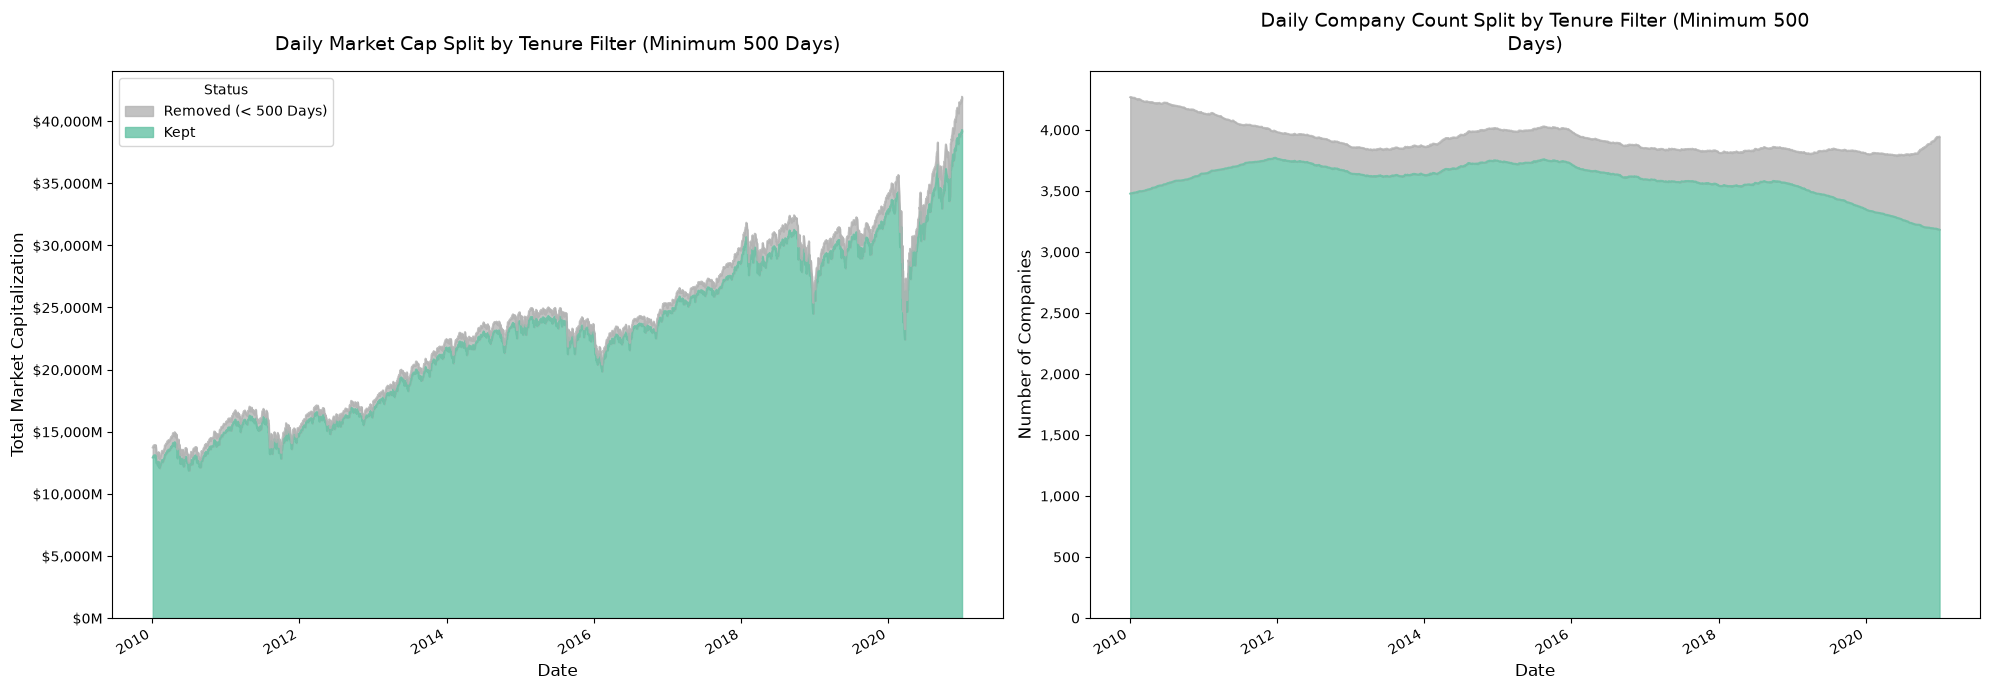

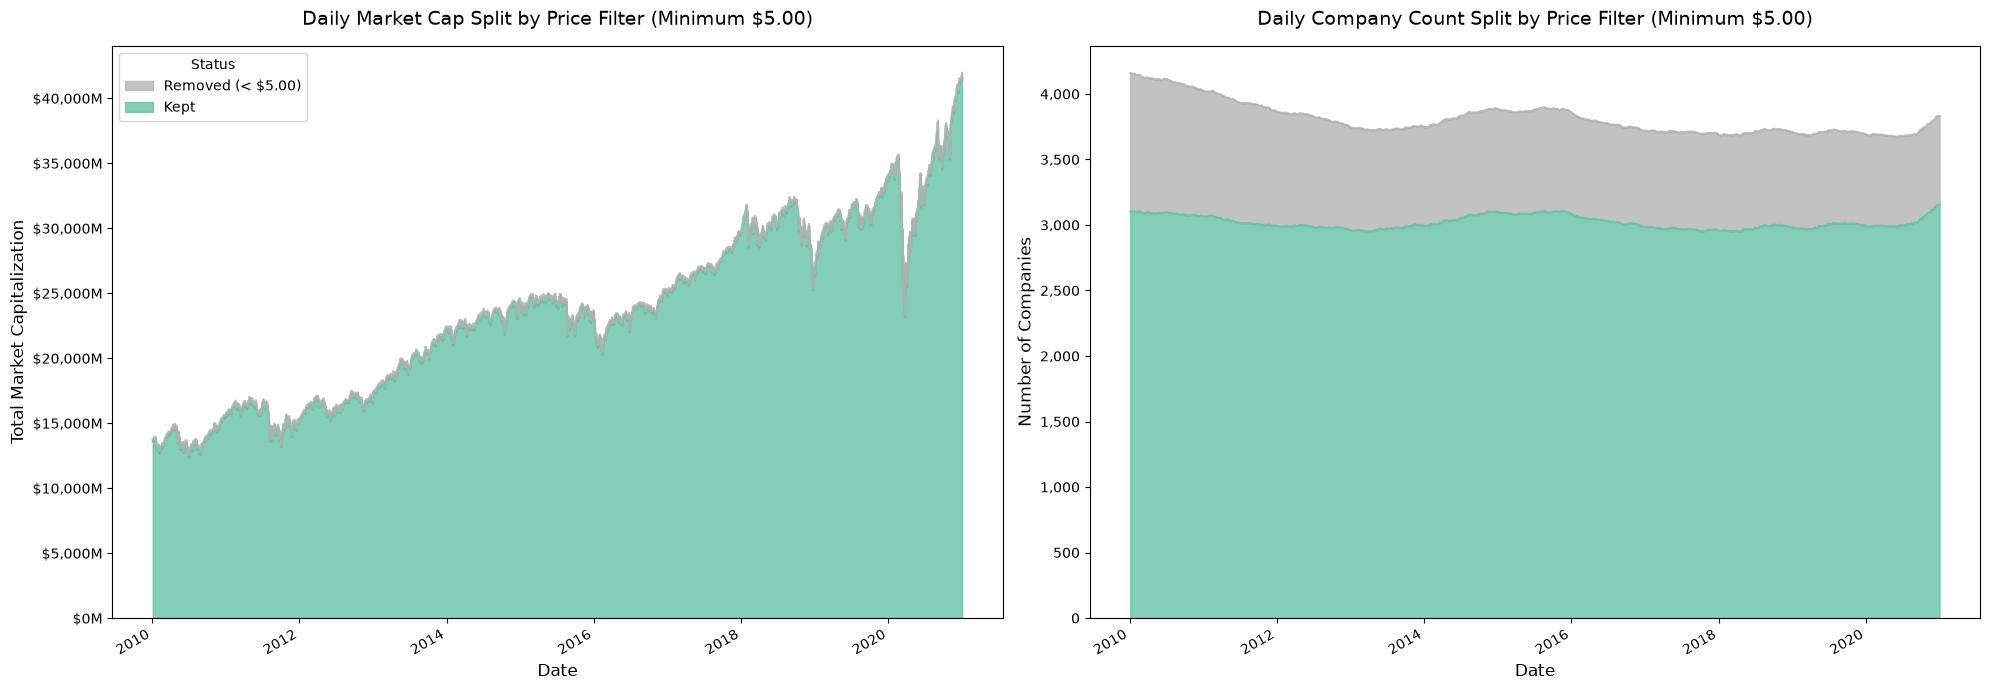

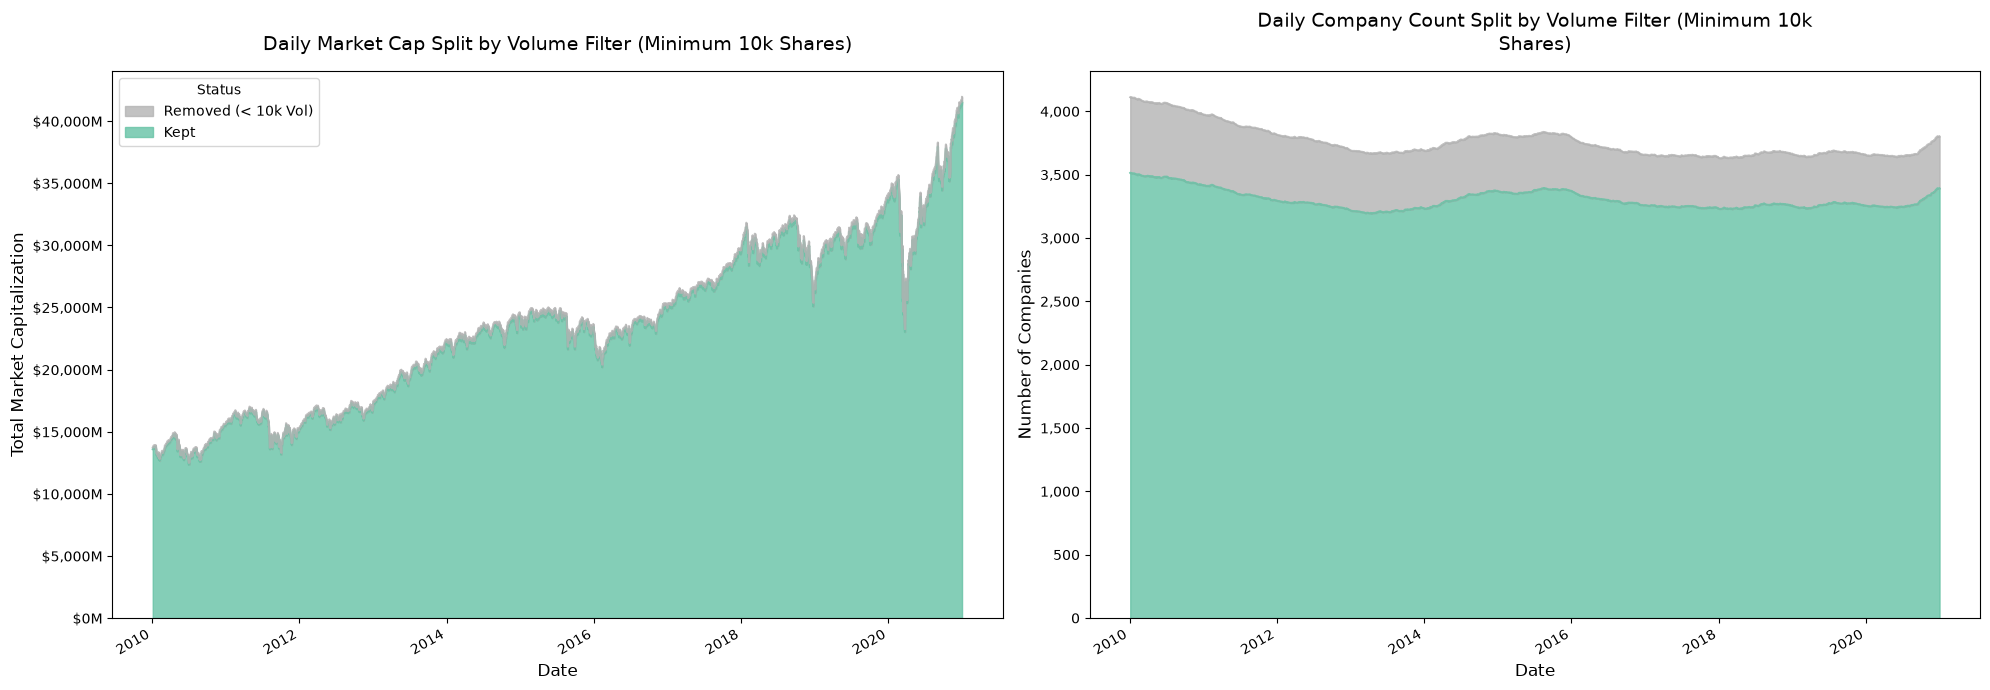

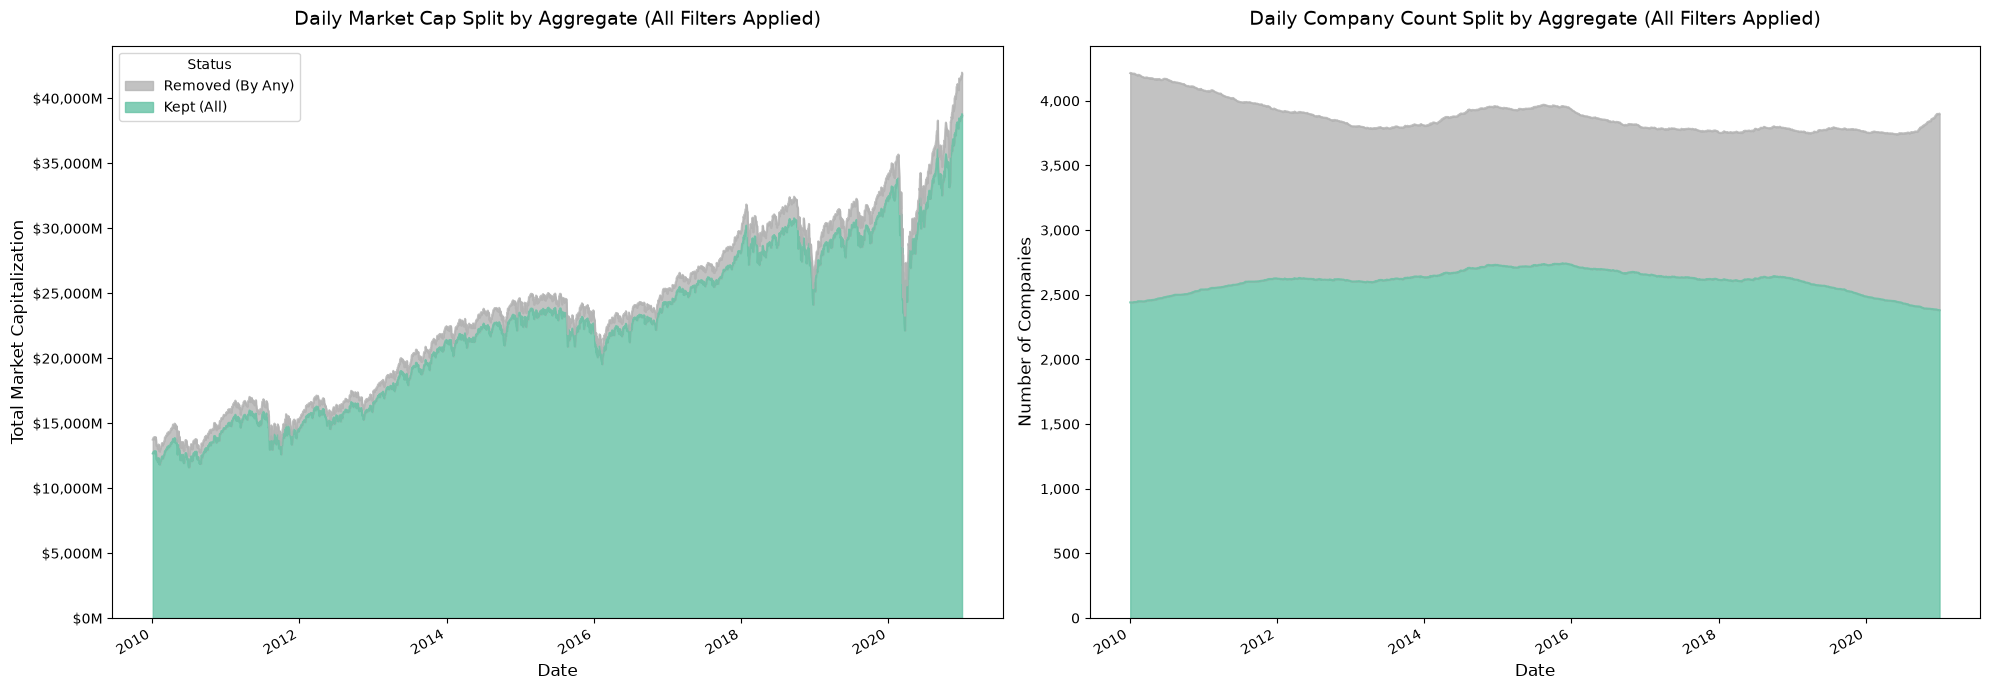

In [11]:

# Sangmin's code copied
stock_stats = dsf.groupby(['permno', 'ticker']).agg(
    n_days        = ('dlycaldt',     'count'),
    date_start    = ('dlycaldt',     'min'),
    date_end      = ('dlycaldt',     'max'),
    median_close  = ('dlyprc', 'median'),   # actual market price (not split-adjusted)
    median_vol    = ('dlyvol', 'median'),
    # mean_pos      = ('pos',      'mean'),
    # mean_neg      = ('neg',      'mean'),
    # signal_std    = ('signal',   'std'),
).reset_index()


print(f'Total stocks before filtering: {len(stock_stats):,}')
print(stock_stats[['n_days','median_close','median_vol']].describe().round(2))
# 2. Define thresholds and categorize each permno
MIN_DAYS = 500
MIN_PRICE = 5.0
MIN_VOL = 10000

# Individual filter classifications
stock_stats['Filter_Days'] = np.where(stock_stats['n_days'] >= MIN_DAYS, 'Kept', 'Removed (< 500 Days)')
stock_stats['Filter_Price'] = np.where(stock_stats['median_close'] >= MIN_PRICE, 'Kept', 'Removed (< $5.00)')
stock_stats['Filter_Vol'] = np.where(stock_stats['median_vol'] >= MIN_VOL, 'Kept', 'Removed (< 10k Vol)')

# Aggregate filter classification
kept_mask = (
    (stock_stats['n_days'] >= MIN_DAYS) & 
    (stock_stats['median_close'] >= MIN_PRICE) & 
    (stock_stats['median_vol'] >= MIN_VOL)
)
stock_stats['Filter_Combined'] = np.where(kept_mask, 'Kept (All)', 'Removed (By Any)')

# 3. Merge classifications back to the daily time-series data
filter_cols = ['permno', 'Filter_Days', 'Filter_Price', 'Filter_Vol', 'Filter_Combined']
dsf_merged = pd.merge(dsf, stock_stats[filter_cols], on='permno', how='left')

#  plot titles
filter_views = {
    'Filter_Days': 'Tenure Filter (Minimum 500 Days)',
    'Filter_Price': 'Price Filter (Minimum $5.00)',
    'Filter_Vol': 'Volume Filter (Minimum 10k Shares)',
    'Filter_Combined': 'Aggregate (All Filters Applied)'
}

# 5. Loop and generate the visualizations
for col, desc in filter_views.items():
    
    # Aggregate Market Cap
    daily_cap = (
        dsf_merged.groupby(['dlycaldt', col])['dlycap']
        .sum()
        .unstack(fill_value=0)
    )
    
    # Aggregate Company Count
    daily_count = (
        dsf_merged.groupby(['dlycaldt', col])['permno']
        .nunique()
        .unstack(fill_value=0)
    )
    
    # keep kept values on bottom
    cols_sorted = sorted(daily_cap.columns)
    daily_cap = daily_cap[cols_sorted]
    daily_count = daily_count[cols_sorted]
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))
    
    # marketcap
    daily_cap.plot(kind='area', stacked=True, alpha=0.8, ax=axes[0], colormap='Set2')
    axes[0].set_title(textwrap.fill(f"Daily Market Cap Split by {desc}", width=60), fontsize=14, pad=15)
    axes[0].set_xlabel("Date", fontsize=12)
    axes[0].set_ylabel("Total Market Capitalization", fontsize=12)
    axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x * 1e-6:,.0f}M'))
    
    handles_cap, labels_cap = axes[0].get_legend_handles_labels()
    axes[0].legend(handles_cap[::-1], labels_cap[::-1], title="Status", loc='upper left')
    
    # company count
    daily_count.plot(kind='area', stacked=True, alpha=0.8, ax=axes[1], colormap='Set2', legend=False)
    axes[1].set_title(textwrap.fill(f"Daily Company Count Split by {desc}", width=60), fontsize=14, pad=15)
    axes[1].set_xlabel("Date", fontsize=12)
    axes[1].set_ylabel("Number of Companies", fontsize=12)
    axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.tight_layout()
    plt.show()